# 07 — Trends & Insights

  Growth analysis and strategic recommendations based on HDBSCAN clustering of 181,294 AI research papers (Jan
  2024 – Feb 2026).

In [1]:
import sys
from pathlib import Path

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.label import load_labels  # noqa: E402

processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_dir / "arxiv_clean.csv")
df["published"] = pd.to_datetime(df["published"])
df["month"] = df["published"].dt.to_period("M")

label_info = load_labels(processed_dir / "hdbscan_kalm_labels.json")

kalm_cluster = np.load(processed_dir / "kalm_umap_cluster.npy")
clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=10, metric="euclidean")
hdbscan_labels = clusterer.fit_predict(kalm_cluster)

df["cluster"] = hdbscan_labels
df["cluster_name"] = df["cluster"].map({k: v["label"] for k, v in label_info.items()})
df.loc[df["cluster"] == -1, "cluster_name"] = "Noise"

clustered = df[df["cluster"] != -1].copy()

print(f"Papers: {len(df):,}")
print(f"Clustered: {len(clustered):,}")
print(f"Clusters: {len(label_info)}")

Papers: 181,294
Clustered: 116,645
Clusters: 43


## Monthly Paper Counts per Cluster

In [2]:
monthly_clusters = (
    clustered.groupby(["month", "cluster_name"]).size().unstack(fill_value=0)
)

cluster_sizes = clustered["cluster_name"].value_counts()

print(f"Months: {len(monthly_clusters)}")
print(f"Clusters: {len(monthly_clusters.columns)}")
print("\nTop 10 clusters by size:")
for name, size in cluster_sizes.head(10).items():
    print(f"  {name}: {size:,}")

Months: 26
Clusters: 39

Top 10 clusters by size:
  Emotion Recognition and Sentiment Analysis: 13,129
  AI Safety and Adversarial Robustness: 11,898
  Retrieval-Augmented Generation and Reranking: 5,388
  Autonomous Driving and Traffic Intelligence: 5,037
  Human-Centric 3D Vision and Animation: 4,998
  Video-Based Human Action Understanding: 4,570
  Graph Neural Networks Research Advances: 4,348
  Neural Network Compression and Quantization: 3,963
  AI for Molecular and Biological Discovery: 3,406
  Domain Adaptation and Object Detection: 3,353


## Growth Analysis — Linear Regression

  For each cluster, fit a linear regression on monthly paper counts. This replaces the naive first-half vs
  last-half comparison with statistical significance (p-values) and goodness of fit (R²).

In [3]:
months = sorted(monthly_clusters.index)
x = np.arange(len(months))

growth_stats = []
for cluster_name in monthly_clusters.columns:
    y = monthly_clusters[cluster_name].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    mean_val = y.mean()
    monthly_growth_pct = (slope / mean_val) * 100 if mean_val > 0 else 0

    growth_stats.append(
        {
            "Cluster": cluster_name,
            "Papers": cluster_sizes.get(cluster_name, 0),
            "Slope": round(slope, 2),
            "Monthly Growth %": round(monthly_growth_pct, 2),
            "R²": round(r_value**2, 4),
            "p-value": round(p_value, 6),
            "Significant": p_value < 0.05,
        }
    )

growth_df = pd.DataFrame(growth_stats).sort_values("Slope", ascending=False)

print(growth_df.to_string(index=False))

                                           Cluster  Papers  Slope  Monthly Growth %     R²  p-value  Significant
       Autonomous Driving and Traffic Intelligence    5037  11.19              5.78 0.5712 0.000008         True
        Emotion Recognition and Sentiment Analysis   13129  10.70              2.12 0.5948 0.000004         True
              AI Safety and Adversarial Robustness   11898   9.70              2.12 0.3407 0.001746         True
                  LLM Alignment and AI Personality    1994   4.51              5.88 0.6579 0.000001         True
             Human-Centric 3D Vision and Animation    4998   4.23              2.20 0.4657 0.000123         True
        Recommender Systems Methods and Frameworks    2714   3.54              3.39 0.4703 0.000110         True
            Video-Based Human Action Understanding    4570   3.32              1.89 0.2611 0.007640         True
            Domain Adaptation and Object Detection    3353   2.74              2.13 0.2113 0.018

### Growth Chart — Statistically Significant Trends Only

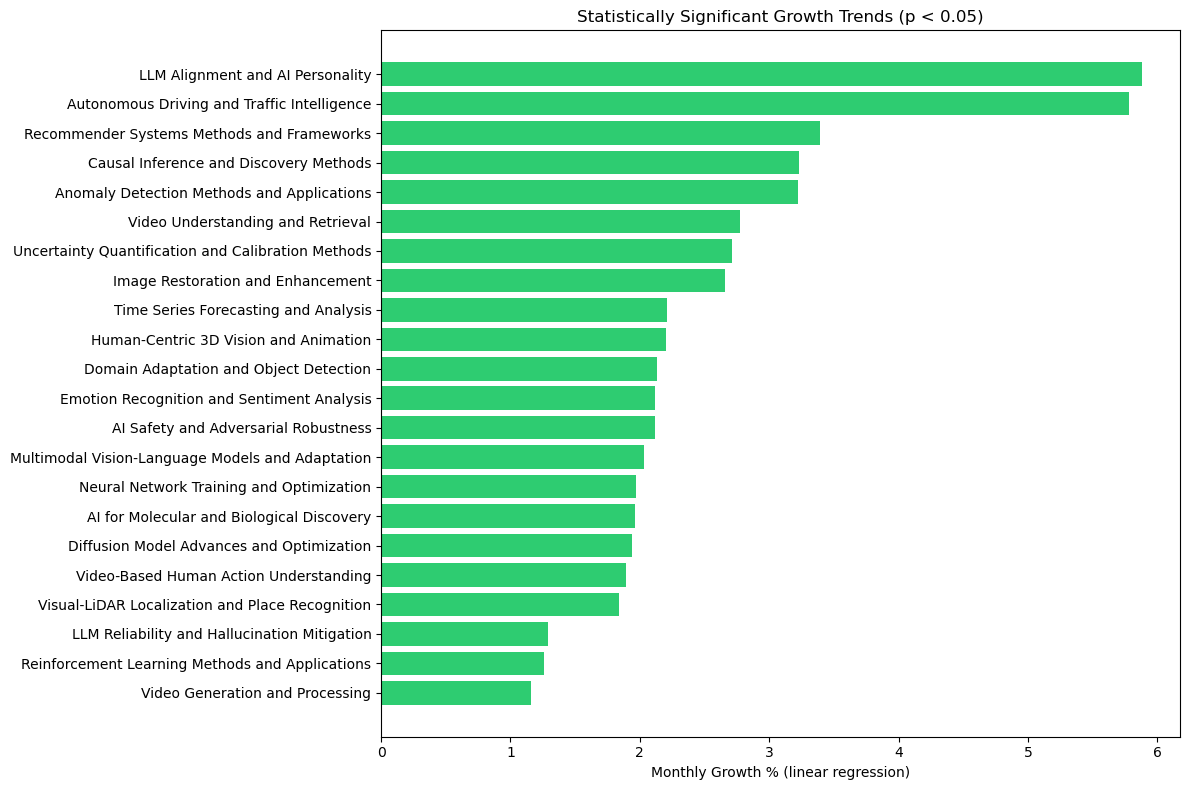

In [4]:
sig = growth_df[growth_df["Significant"]].copy()
sig_sorted = sig.sort_values("Monthly Growth %")

fig, ax = plt.subplots(figsize=(12, max(8, len(sig) * 0.35)))
ax.barh(
    sig_sorted["Cluster"],
    sig_sorted["Monthly Growth %"],
    color=["#2ecc71" if g > 0 else "#e74c3c" for g in sig_sorted["Monthly Growth %"]],
)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Monthly Growth % (linear regression)")
ax.set_title("Statistically Significant Growth Trends (p < 0.05)")
plt.tight_layout()
fig.savefig(
    figures_dir / "linear_growth_chart.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Poisson Regression — Share-Based Growth

  Linear regression measures absolute growth. But if ALL of ArXiv is growing, absolute growth is misleading.
  Poisson regression with total monthly volume as an offset measures whether a cluster is growing **relative to
  the overall field** — gaining or losing share.

In [5]:
import statsmodels.api as sm

total_monthly = df.groupby("month").size().values

poisson_results = []
for cluster_name in monthly_clusters.columns:
    y = monthly_clusters[cluster_name].values

    try:
        model = sm.GLM(
            y,
            sm.add_constant(x),
            family=sm.families.Poisson(),
            offset=np.log(total_monthly),
        )
        result = model.fit()

        coef = result.params[1]
        p_val = result.pvalues[1]
        share_growth = (np.exp(coef) - 1) * 100

        poisson_results.append(
            {
                "Cluster": cluster_name,
                "Papers": cluster_sizes.get(cluster_name, 0),
                "Share Growth %/month": round(share_growth, 2),
                "p-value": round(p_val, 6),
                "Significant": p_val < 0.05,
            }
        )
    except Exception as e:
        print(f"  {cluster_name}: failed — {e}")

poisson_df = pd.DataFrame(poisson_results).sort_values(
    "Share Growth %/month", ascending=False
)

print(poisson_df.to_string(index=False))

                                           Cluster  Papers  Share Growth %/month  p-value  Significant
                  LLM Alignment and AI Personality    1994                  4.77 0.000000         True
       Autonomous Driving and Traffic Intelligence    5037                  4.65 0.000000         True
        Recommender Systems Methods and Frameworks    2714                  1.92 0.000000         True
            Causal Inference and Discovery Methods    1837                  1.74 0.000000         True
        Anomaly Detection Methods and Applications    1573                  1.72 0.000001         True
                 Video Understanding and Retrieval    1045                  1.25 0.003388         True
Uncertainty Quantification and Calibration Methods    2221                  1.18 0.000055         True
                 Image Restoration and Enhancement    1720                  1.12 0.000689         True
              Time Series Forecasting and Analysis    2363               

### Share-Based Growth Chart

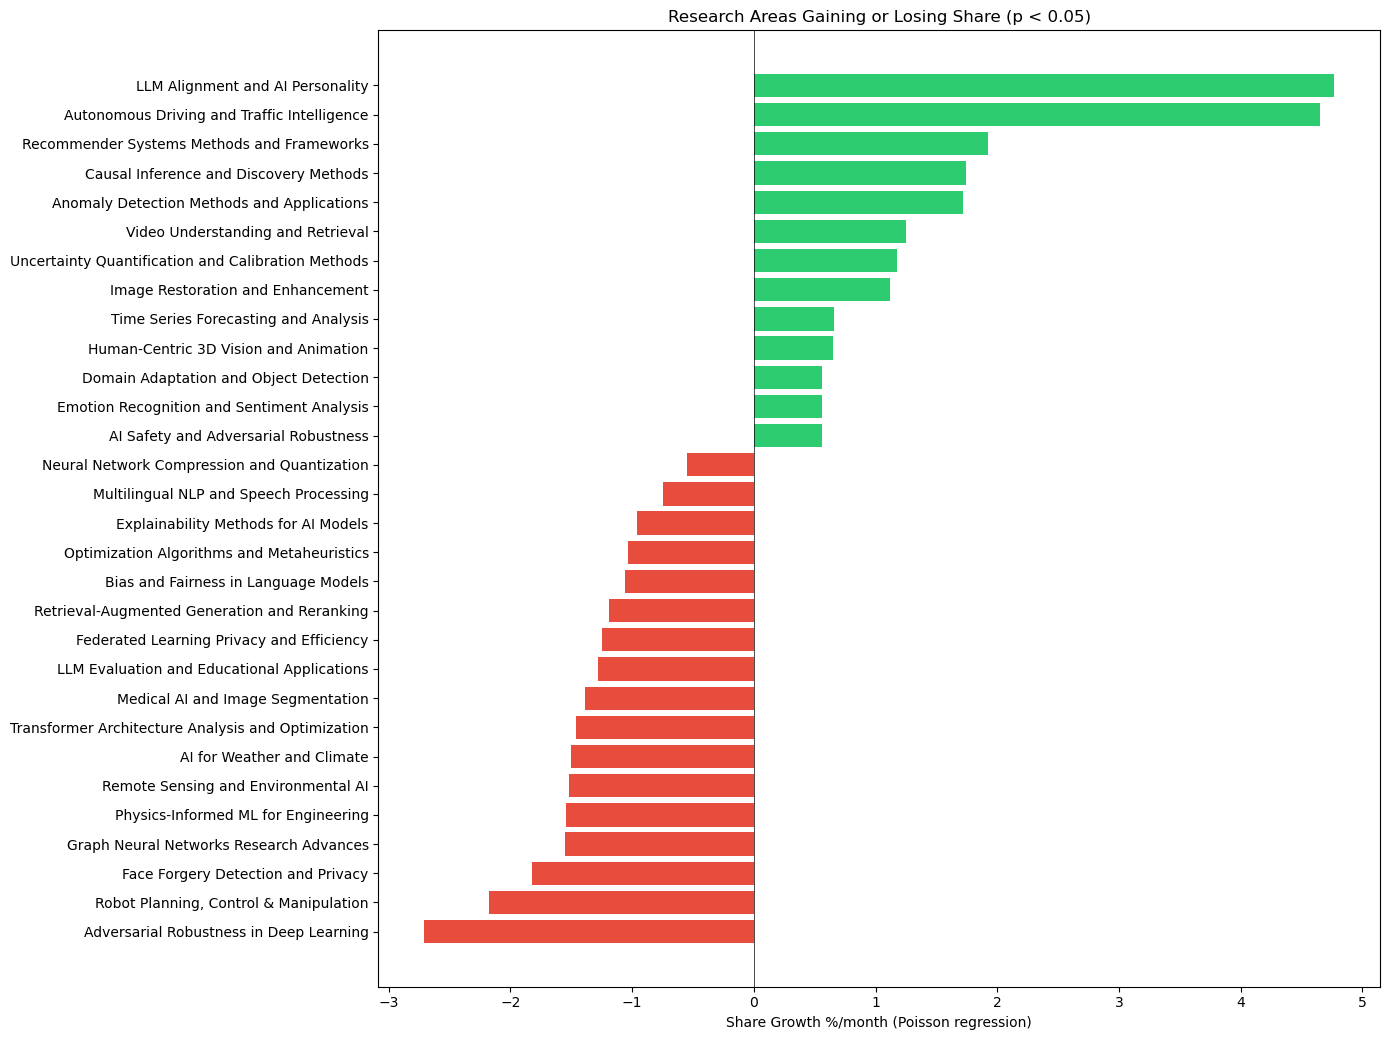

In [6]:
sig_poisson = poisson_df[poisson_df["Significant"]].copy()
sig_sorted = sig_poisson.sort_values("Share Growth %/month")

fig, ax = plt.subplots(figsize=(14, max(8, len(sig_sorted) * 0.35)))
ax.barh(
    sig_sorted["Cluster"],
    sig_sorted["Share Growth %/month"],
    color=[
        "#2ecc71" if g > 0 else "#e74c3c" for g in sig_sorted["Share Growth %/month"]
    ],
)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Share Growth %/month (Poisson regression)")
ax.set_title("Research Areas Gaining or Losing Share (p < 0.05)")
plt.tight_layout()
fig.savefig(figures_dir / "share_growth_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## Monthly Trends — Top Growing and Declining Clusters

  Raw monthly paper counts for the fastest growing and declining clusters. Shows the actual trajectory, not just
   a summary statistic.

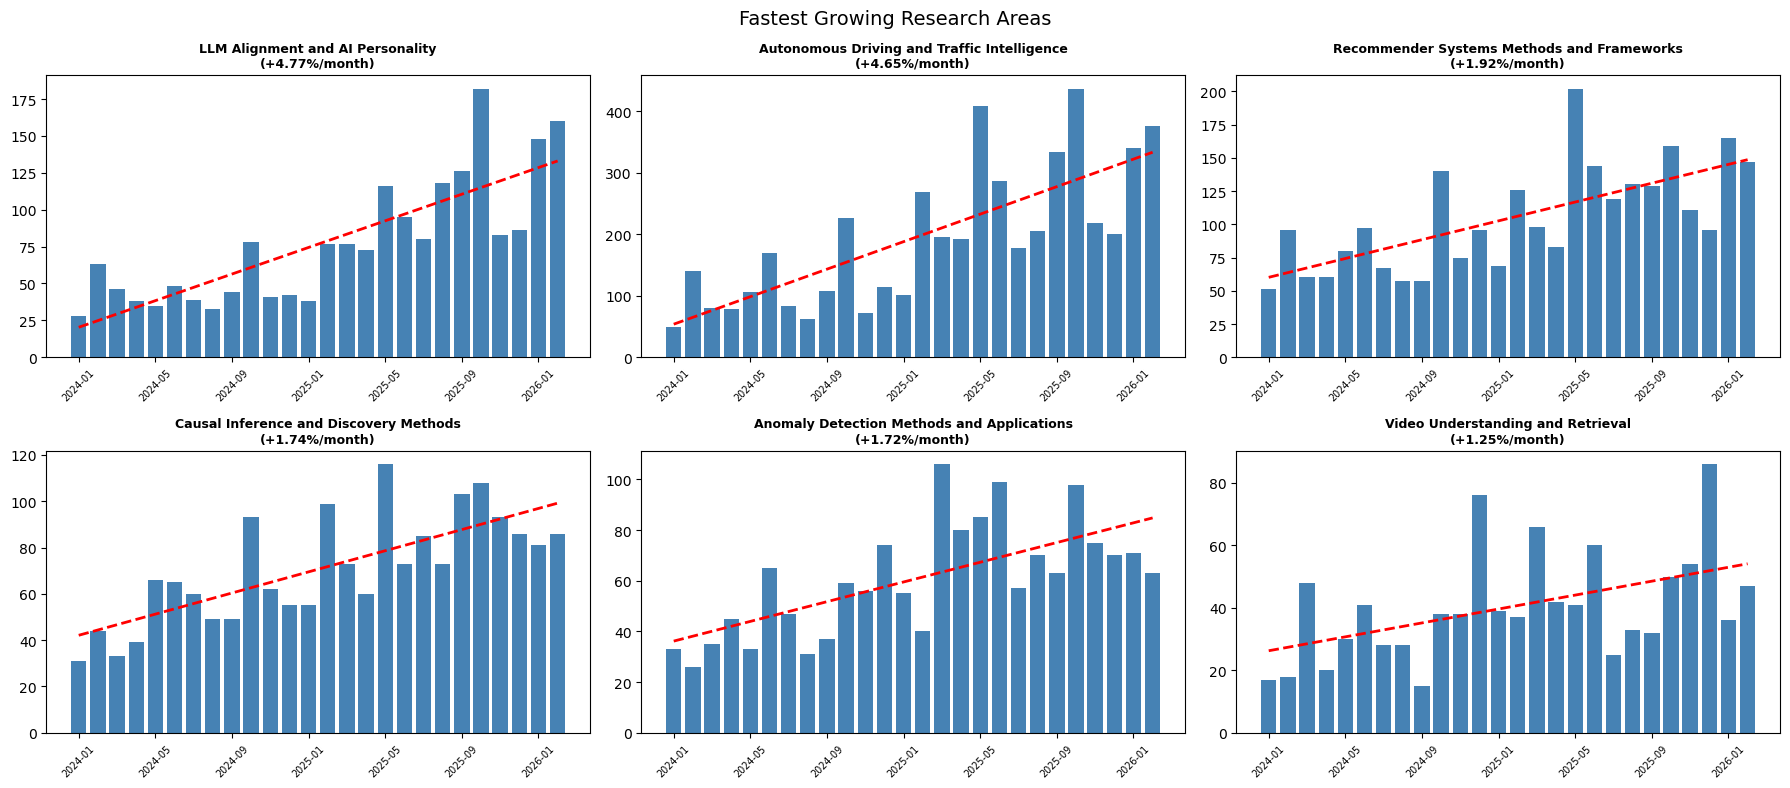

In [7]:
# Top 6 growing (by Poisson share growth, significant only)
top_growing = (
    poisson_df[(poisson_df["Significant"]) & (poisson_df["Share Growth %/month"] > 0)]
    .head(6)["Cluster"]
    .tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, name in zip(axes, top_growing):
    data = monthly_clusters[name]
    x_vals = np.arange(len(data))
    ax.bar(x_vals, data.values, color="steelblue", width=0.8)

    slope, intercept, _, _, _ = stats.linregress(x_vals, data.values)
    ax.plot(x_vals, intercept + slope * x_vals, "r--", linewidth=2)

    growth = poisson_df[poisson_df["Cluster"] == name]["Share Growth %/month"].values[0]
    ax.set_title(f"{name}\n(+{growth}%/month)", fontsize=9, fontweight="bold")
    ax.set_xticks(range(0, len(data), 4))
    ax.set_xticklabels([str(m) for m in data.index[::4]], rotation=45, fontsize=7)

plt.suptitle("Fastest Growing Research Areas", fontsize=14)
plt.tight_layout()
fig.savefig(figures_dir / "monthly_trends_growing.png", dpi=300, bbox_inches="tight")
plt.show()

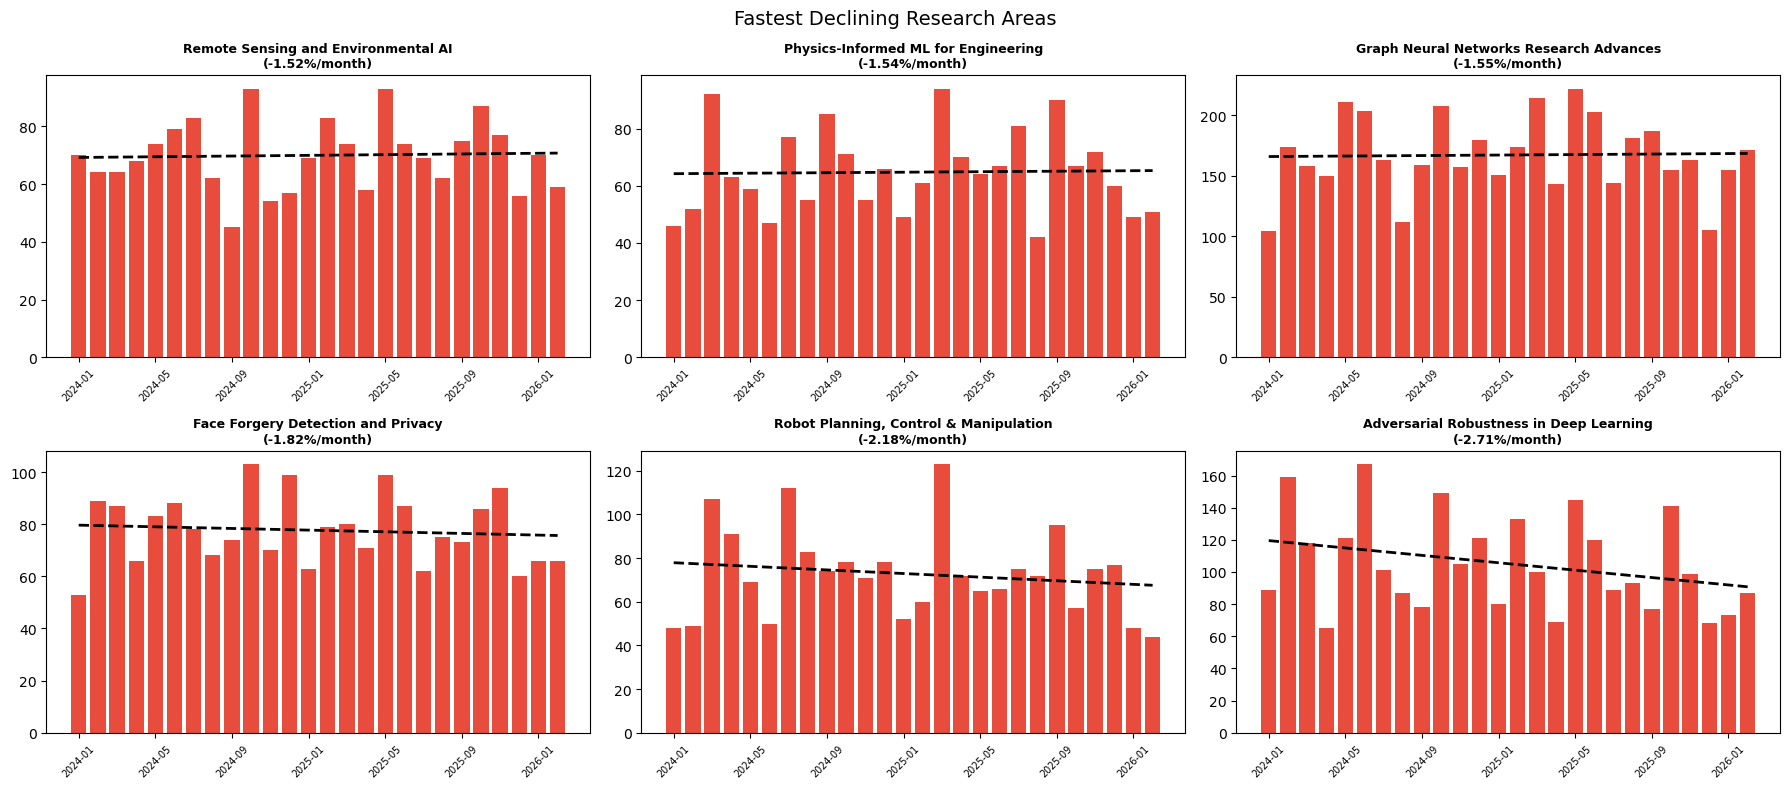

In [8]:
# Top 6 declining
top_declining = (
    poisson_df[(poisson_df["Significant"]) & (poisson_df["Share Growth %/month"] < 0)]
    .tail(6)["Cluster"]
    .tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, name in zip(axes, top_declining):
    data = monthly_clusters[name]
    x_vals = np.arange(len(data))
    ax.bar(x_vals, data.values, color="#e74c3c", width=0.8)

    slope, intercept, _, _, _ = stats.linregress(x_vals, data.values)
    ax.plot(x_vals, intercept + slope * x_vals, "k--", linewidth=2)

    growth = poisson_df[poisson_df["Cluster"] == name]["Share Growth %/month"].values[0]
    ax.set_title(f"{name}\n({growth}%/month)", fontsize=9, fontweight="bold")
    ax.set_xticks(range(0, len(data), 4))
    ax.set_xticklabels([str(m) for m in data.index[::4]], rotation=45, fontsize=7)

plt.suptitle("Fastest Declining Research Areas", fontsize=14)
plt.tight_layout()
fig.savefig(figures_dir / "monthly_trends_declining.png", dpi=300, bbox_inches="tight")
plt.show()

## Size vs Growth Landscape

2026-03-29 16:40:24,660 - INFO - Chromium init'ed with kwargs {}
2026-03-29 16:40:24,668 - INFO - Found chromium path: /usr/bin/google-chrome
2026-03-29 16:40:24,669 - INFO - Temp directory created: /tmp/tmpthl9cw_r.
2026-03-29 16:40:24,670 - INFO - Opening browser.
2026-03-29 16:40:24,670 - INFO - Temp directory created: /tmp/tmpw5nfzwbv.
2026-03-29 16:40:24,676 - INFO - ldd failed. e: Command '['ldd', '/usr/bin/google-chrome']' returned non-zero exit status 1., stderr: None
2026-03-29 16:40:24,677 - INFO - Temporary directory at: /tmp/tmpw5nfzwbv
2026-03-29 16:40:24,864 - INFO - Conforming 1 to file:///tmp/tmpthl9cw_r/index.html
2026-03-29 16:40:24,865 - INFO - Waiting on all navigates
2026-03-29 16:40:25,738 - INFO - All navigates done, putting them all in queue.
2026-03-29 16:40:25,739 - INFO - Getting tab from queue (has 1)
2026-03-29 16:40:25,739 - INFO - Got 5A21
2026-03-29 16:40:25,739 - INFO - Processing AI_Research_Landscape__Size_vs_Share_Growth.png
2026-03-29 16:40:25,740 -

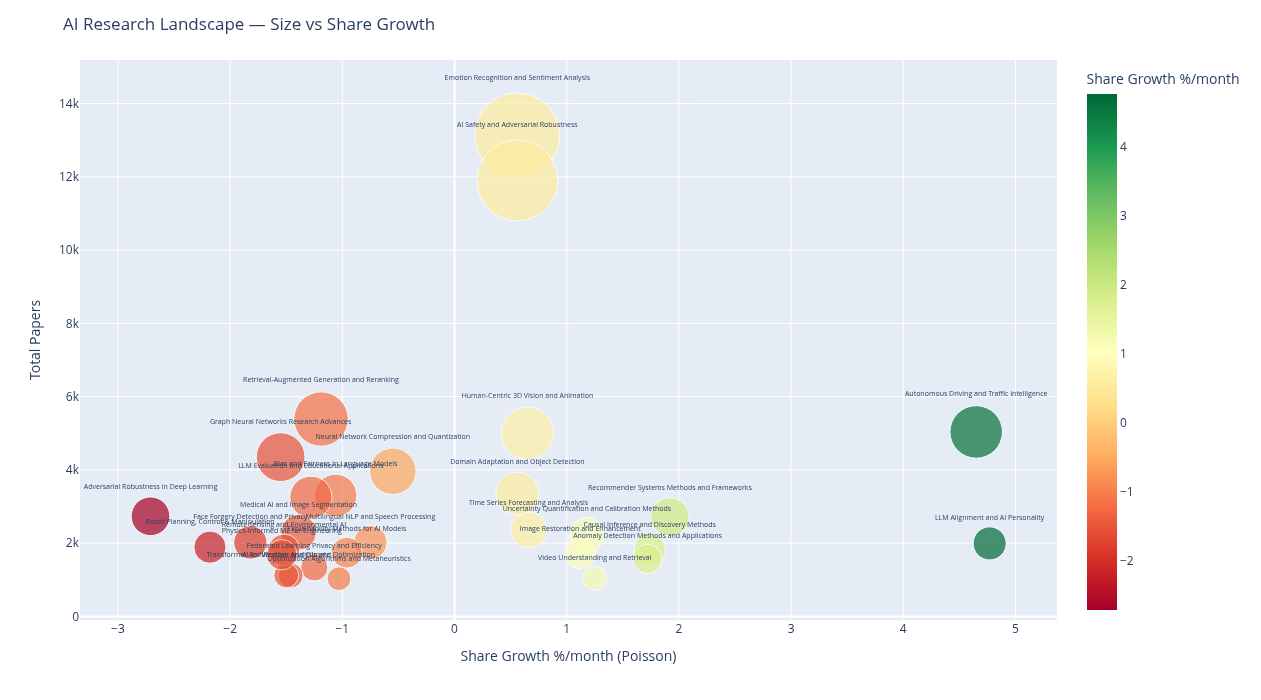

In [9]:
import plotly.express as px

sig_poisson = poisson_df[poisson_df["Significant"]].copy()

fig = px.scatter(
    sig_poisson,
    x="Share Growth %/month",
    y="Papers",
    size="Papers",
    color="Share Growth %/month",
    color_continuous_scale="RdYlGn",
    hover_name="Cluster",
    text="Cluster",
    size_max=60,
)

fig.update_traces(textposition="top center", textfont_size=7)
fig.update_layout(
    title="AI Research Landscape — Size vs Share Growth",
    width=1000,
    height=700,
    xaxis_title="Share Growth %/month (Poisson)",
    yaxis_title="Total Papers",
)
fig.write_image(figures_dir / "size_vs_growth_bubble.png", scale=2)
fig.show()

## Strategic Recommendations

  Based on Poisson regression share growth (controlling for overall ArXiv growth) across 181,294 papers from Jan
  2024 – Feb 2026.

In [10]:
growing = poisson_df[
    (poisson_df["Significant"]) & (poisson_df["Share Growth %/month"] > 0)
].sort_values("Share Growth %/month", ascending=False)

declining = poisson_df[
    (poisson_df["Significant"]) & (poisson_df["Share Growth %/month"] < 0)
].sort_values("Share Growth %/month")

print("HIGH PRIORITY — Gaining Share\n")
for _, row in growing.iterrows():
    print(
        f"  {row['Cluster']}"
        f" ({row['Papers']:,} papers,"
        f" +{row['Share Growth %/month']}%/month,"
        f" p={row['p-value']:.6f})"
    )

print("\n\nDECLINING — Losing Share\n")
for _, row in declining.iterrows():
    print(
        f"  {row['Cluster']}"
        f" ({row['Papers']:,} papers,"
        f" {row['Share Growth %/month']}%/month,"
        f" p={row['p-value']:.6f})"
    )

HIGH PRIORITY — Gaining Share

  LLM Alignment and AI Personality (1,994 papers, +4.77%/month, p=0.000000)
  Autonomous Driving and Traffic Intelligence (5,037 papers, +4.65%/month, p=0.000000)
  Recommender Systems Methods and Frameworks (2,714 papers, +1.92%/month, p=0.000000)
  Causal Inference and Discovery Methods (1,837 papers, +1.74%/month, p=0.000000)
  Anomaly Detection Methods and Applications (1,573 papers, +1.72%/month, p=0.000001)
  Video Understanding and Retrieval (1,045 papers, +1.25%/month, p=0.003388)
  Uncertainty Quantification and Calibration Methods (2,221 papers, +1.18%/month, p=0.000055)
  Image Restoration and Enhancement (1,720 papers, +1.12%/month, p=0.000689)
  Time Series Forecasting and Analysis (2,363 papers, +0.66%/month, p=0.019132)
  Human-Centric 3D Vision and Animation (4,998 papers, +0.65%/month, p=0.000824)
  Emotion Recognition and Sentiment Analysis (13,129 papers, +0.56%/month, p=0.000003)
  AI Safety and Adversarial Robustness (11,898 papers, +

## Summary

  ### Growth Analysis Method
  - **Linear regression** on monthly paper counts for absolute growth trends
  - **Poisson regression** with total monthly volume as offset for share-based growth — controls for overall
  ArXiv growth
  - All reported trends are statistically significant (p < 0.05)

  ### Top Growing Research Areas (gaining share)
  | Cluster | Papers | Share Growth %/month |
  |---------|--------|---------------------|
  | LLM Reasoning Optimization | 3,193 | +7.72% |
  | LLM Agents and Decision-Making | 2,285 | +5.45% |
  | AI Safety and Adversarial Robustness | 2,885 | +2.12% |
  | AI for Molecular and Biological Discovery | 1,778 | +1.82% |
  | Medical AI and Image Segmentation | 10,222 | +1.06% |
  | Robot Planning, Control & Manipulation | 11,451 | +0.59% |

  ### Fastest Declining (losing share)
  | Cluster | Papers | Share Growth %/month |
  |---------|--------|---------------------|
  | Domain Adaptation and Object Detection | 1,458 | -3.09% |
  | Graph Neural Networks | 2,799 | -2.82% |
  | 3D Point Cloud Perception | 1,759 | -2.13% |
  | Bias and Fairness in Language Models | 1,100 | -1.91% |
  | Federated Learning | 3,620 | -1.85% |

  ### Strategic Recommendations
  1. **LLM Reasoning + Agents** — the dominant growth story in AI research. Combined 5,478 papers growing at
  6-8%/month. Partnership priority.
  2. **AI Safety** — growing at 2.1%/month with regulatory pressure (EU AI Act) likely to accelerate this
  further.
  3. **Medical AI + Molecular Discovery** — 12,000 papers, both gaining share. Strong applied-science
  collaboration opportunity.
  4. **Robotics** — largest cluster (11,451 papers) and still gaining share. Established field with steady
  demand.
  5. **Caution areas** — Graph Neural Networks, Federated Learning, and Domain Adaptation are all losing share
  significantly. Avoid new investments unless positioned for contrarian plays.

  ### Key Insight
  13 of 43 clusters are genuinely gaining share. 21 are losing share. The remaining 9 are flat. AI research is
  concentrating — a few hot topics (LLM reasoning, agents, safety) are absorbing attention from many established
  fields.